In [1]:
library(Signac)
library(Seurat)
library(JASPAR2024)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: BiocFileCache

Loading required package: dbplyr

Loading required package: GenomeInfoDb

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, r

In [6]:
path_rds = "/nfs/home/students/m.back/swarm/backend/uploads/job_1768478211396_76193c44-3781-4b8b-b9ef-fc7702b4a617/plasmidpoop/global_motif_analysis.rds"

onj <- readRDS(path_rds)

In [12]:
onj@misc$diff_motif_activity

,p_val,avg_diff,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0084.2,6.511145e-21,1.3804320,0.677,0.241,4.688024e-18
MA0625.3,9.994257e-19,1.2955614,0.683,0.233,7.195865e-16
MA0077.2,1.858964e-17,1.2332200,0.713,0.308,1.338454e-14
MA0868.3,1.554051e-16,1.1796802,0.628,0.233,1.118917e-13
MA0143.5,6.208655e-16,1.2662303,0.634,0.301,4.470232e-13
MA1120.2,6.208655e-16,1.2662303,0.634,0.301,4.470232e-13
MA1152.2,6.208655e-16,1.2662303,0.634,0.301,4.470232e-13
MA1563.2,7.586184e-16,1.1602463,0.665,0.263,5.462052e-13
MA1638.2,2.284741e-15,0.9772739,0.610,0.256,1.645014e-12


In [7]:
onj@misc$differential_motif_activity

NULL

In [2]:
path_rds = "/nfs/home/students/m.back/swarm/backend/uploads/job_1765704415143_ff39eb2f-8a8f-4650-b124-1ee2777994f7/kackhaufen1/global_motif_analysis.rds"
seurat_obj <- readRDS(path_rds)

In [3]:
str(seurat_obj[["peaks"]]@motifs)

Formal class 'Motif' [package "Signac"] with 5 slots
  ..@ data       :Formal class 'lgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:9670656] 5 83 116 125 192 331 460 543 549 594 ...
  .. .. ..@ p       : int [1:721] 0 4499 15659 22512 34203 47253 58466 72692 146668 192772 ...
  .. .. ..@ Dim     : int [1:2] 165040 720
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:165040] "chr1-9949-10530" "chr1-17247-17528" "chr1-88077-88293" "chr1-180659-181625" ...
  .. .. .. ..$ : chr [1:720] "MA0069.1" "MA0071.1" "MA0074.1" "MA0101.1" ...
  .. .. ..@ x       : logi [1:9670656] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. ..@ factors : list()
  ..@ pwm        :List of 720
  .. ..$ MA0069.1: int [1:4, 1:14] 2 4 4 33 2 2 0 39 4 26 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:4] "A" "C" "G" "T"
  .. .. .. ..$ : NULL
  .. ..$ MA0071.1: int [1:4, 1:10] 15 1 2 7 9 1 0 15 6 12 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:4] "A

In [5]:
library(JASPAR2024) 
library(TFBSTools)
jaspar <- JASPAR2024()
sq24 <- RSQLite::dbConnect(RSQLite::SQLite(), db(jaspar))
motifs24 <- TFBSTools::getMatrixSet(sq24, list(species = "Homo sapiens", collection = "CORE"))

In [6]:
motif_to_tf <- data.frame(
  motif_id = vapply(motifs24, TFBSTools::ID, character(1)),
  TF       = vapply(motifs24, TFBSTools::name, character(1)),
  stringsAsFactors = FALSE
)


In [ ]:
out_path = "/nfs/home/students/m.back/swarm/backend/uploads/job_1765704415143_ff39eb2f-8a8f-4650-b124-1ee2777994f7/kackhaufen1/"
write.csv(motif_to_tf, file = file.path(out_path, "motif_to_tf.csv"), row.names = FALSE)

In [7]:
motif_to_tf

,motif_id,TF
,<chr>,<chr>
MA0069.1,MA0069.1,PAX6
MA0071.1,MA0071.1,RORA
MA0074.1,MA0074.1,RXRA::VDR
MA0101.1,MA0101.1,REL
MA0107.1,MA0107.1,RELA
MA0115.1,MA0115.1,NR1H2::RXRA
MA0119.1,MA0119.1,NFIC::TLX1
MA0130.1,MA0130.1,ZNF354C
MA0149.1,MA0149.1,EWSR1-FLI1


### test footsprinting spatial data

In [ ]:
plot_footprint_for_motif <- function(
  M_path, # eg adata_map.X.csv
  spot_obj_path,
  motif_name,
  object_dissociated = NULL,
  object_dissociated_path = NULL,
  assay = "peaks",
  clustering_var = "leiden",
  object_dissociated_out_path = object_dissociated_path,
  spot_obj_out_path = spot_obj_path,
  plot_out_path = NULL,
  overwrite = TRUE
) {

  # Safety checks for overwrite behavior
  if (!overwrite) {
    if (file.exists(object_dissociated_out_path)) {
      stop("Refusing to overwrite existing file: ", object_dissociated_out_path)
    }
    if (file.exists(spot_obj_out_path)) {
      stop("Refusing to overwrite existing file: ", spot_obj_out_path)
    }
  }
  if (is.null(object_dissociated)) {
    if (is.null(object_dissociated_path)) {
      stop("Either object_dissociated or object_dissociated_path must be provided.")
    }
    object_dissociated <- readRDS(object_dissociated_path)
  }
  M <- read.csv(M_path, row.names = 1, check.names = FALSE)
  spot_obj <- readRDS(spot_obj_path)

  key <- sprintf("footprint_%s", paste(motif_name))

  print(" Computing footprint in dissociated object...")
  # Compute footprint in dissociated object
  object_dissociated <- Signac::Footprint(
    object = object_dissociated,
    motif.name = motif_name,
    genome = BSgenome.Hsapiens.UCSC.hg38,
    in.peaks = TRUE,
    key = key
  )

  print(" Projecting footprint to spots...")
  # Project dissociated footprint to spots
  fp_spots_all <- footprints_dissociated2spatial(
    object_dissociated = object_dissociated,
    footprint_key = key,
    M = M,
    assay = assay
  )

  # Store in spot object
  spot_obj[[assay]]@positionEnrichment[[key]] <- fp_spots_all
  Seurat::Idents(spot_obj) <- clustering_var

  # Persist updated objects to disk
  saveRDS(object_dissociated, file = object_dissociated_out_path)
  saveRDS(spot_obj, file = spot_obj_out_path)

  # Plot
  p <- Signac::PlotFootprint(
    object = spot_obj,
    features = key,
    group.by = clustering_var,
    show.expected = TRUE,
    normalization = "subtract"
  )
  if (!is.null(plot_out_path)) {
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }else{
    plot_out_path <- file.path(dirname(spot_obj_out_path),paste0("footprint_", motif_name, ".pdf"))
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }

  return(p)
}

In [9]:
footprints_dissociated2spatial <- function(
  object_dissociated,
  footprint_key,
  M,
  assay = "peaks"
) {
  fp_all <- object_dissociated[[assay]]@positionEnrichment[[footprint_key]]

  cells <- colnames(object_dissociated)
  print("Filtering footprint to dissociated cells...")
  fp <- fp_all[intersect(rownames(fp_all), cells), , drop = FALSE]

  common <- intersect(rownames(M), rownames(fp))
  if (length(common) == 0) stop("No overlap between rownames(M) and footprint cell names.")
  fp <- fp[common, , drop = FALSE]
  M  <- M[common, , drop = FALSE]

  print("Reading Matrix M")

  M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)

  spot_sum <- Matrix::t(M_sp) %*% fp                 # spots x positions
  w_spot   <- Matrix::colSums(M_sp)                  # weights per spot

  Dinv <- Matrix::Diagonal(x = 1 / pmax(as.numeric(w_spot), 1e-12))
  spot_mean <- Dinv %*% spot_sum                     # weighted mean per spot

  rownames(spot_mean) <- colnames(M_sp)

  expected <- fp_all["expected", , drop = FALSE]
  motif    <- fp_all["motif", , drop = FALSE]
  print("Combining results with rbind...")
  rbind(spot_mean, expected, motif)
}


In [ ]:
spot_rds_path <- "../backend/uploads/job_1769089431977_290266c5-552d-4cc8-95c2-97f7c42e0628/dumpase1/spot_obj.rds"

In [5]:
spot_rds <- readRDS(spot_rds)

In [6]:
spot_rds

An object of class Seurat 
165040 features across 1448 samples within 1 assay 
Active assay: peaks (165040 features, 0 variable features)
 2 layers present: counts, data

In [18]:
object_dis <- readRDS(object_dissociated_path)

In [22]:
Fragments(object = object_dis)[[1]]@path

[1] "/workspaces/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"

In [24]:
fpath <- "../backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
fragments <- CreateFragmentObject(path = fpath, cells = colnames(object_dis),validate.fragments = FALSE)
Fragments(object_dis[["peaks"]]) <- fragments

Computing hash



ERROR: Error in AddFragments(object = object, fragments = value): Cells already present in a fragment object


In [25]:
Fragments(object = object_dis)[[1]]@path <- fpath

ERROR: Error in AddFragments(object = object, fragments = value[[i]]): Cells already present in a fragment object


In [2]:
M_path <- file.path("../backend/uploads/job_1769093628114_0d868d61-14bf-47d7-ad6a-d53ad10aa1b6/dumpase1/adata_map.X.csv")
motif_name <- "MA0084.2"
object_dissociated_path <- "../backend/uploads/job_1769093628114_0d868d61-14bf-47d7-ad6a-d53ad10aa1b6/healthy_breast_preprocessed_RNA_peaks_only.rds"
spot_rds_path <- "../backend/uploads/job_1769089431977_290266c5-552d-4cc8-95c2-97f7c42e0628/dumpase1/spot_obj.rds"
spot_rds_path_out <- "../backend/uploads/job_1769089431977_290266c5-552d-4cc8-95c2-97f7c42e0628/dumpase1/spot_obj_w_footprint.rds"

In [3]:
object_dissociated <- readRDS(object_dissociated_path)

fr <- Fragments(object_dissociated[["peaks"]])[[1]]

# Full path Signac will use
frag_path <- fr@path
frag_path

[1] "/workspaces/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"

In [4]:
library(Signac)

obj <- readRDS(object_dissociated_path)

# remove all existing fragment objects
Fragments(obj[["peaks"]]) <- NULL

frag_path_host <- "/nfs/home/students/m.back/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
stopifnot(file.exists(frag_path_host))
stopifnot(file.exists(paste0(frag_path_host, ".tbi")))

new_frag <- CreateFragmentObject(
  path = frag_path_host,
  cells = colnames(obj),
  validate.fragments = FALSE
)

# now attach
Fragments(obj[["peaks"]]) <- new_frag

# verify
Fragments(obj[["peaks"]])[[1]]@path


Computing hash



[1] "/nfs/home/students/m.back/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"

In [8]:
object_dissociated_path_out <- "../backend/uploads/job_1769093628114_0d868d61-14bf-47d7-ad6a-d53ad10aa1b6/healthy_breast_preprocessed_RNA_peaks_only_w_footprint.rds"

plot_footprint_for_motif(
        M_path = M_path, # eg adata_map.X.csv
        spot_obj_path = spot_rds_path,
        motif_name = motif_name,
        object_dissociated = obj,
        #object_dissociated_path = object_dissociated_path, # wont be used since object_dissociated is provided
        assay = "peaks",
        clustering_var = "leiden",
        object_dissociated_out_path = object_dissociated_path_out,
        spot_obj_out_path = spot_rds_path_out,
        plot_out_path = NULL,
        overwrite = TRUE)

[1] " Computing footprint in dissociated object..."


Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



[1] " Projecting footprint to spots..."


ERROR: Error in .subscript.2ary(x, i, , drop = drop): subscript out of bounds


In [10]:
 
spot_rds_w_footprint <- readRDS(spot_rds_path_out)

In [11]:
spot_rds_w_footprint@assays$peaks@positionEnrichment$footprint_MA0084.2

  [[ suppressing 32 column names ‘-253’, ‘-252’, ‘-251’ ... ]]



1450 x 507 sparse Matrix of class "dgCMatrix"
                                                                            
AAACACCAATAACTGC-1 1.2075374 1.1193537 1.2148813 1.765290 1.7292145 1.721181
AAACAGCTTTCAGAAG-1 1.1049100 1.1185603 1.0897448 1.791467 1.7061717 1.622180
AAACAGGGTCTATATT-1 1.1217513 1.0121311 1.0764767 1.768198 1.6594351 1.770227
AAACCGGGTAGGTACC-1 1.1918767 1.1426990 1.1348558 1.854055 1.7670390 1.841937
AAACCTCATGAAGTTG-1 1.1750479 1.1454772 1.1508318 1.673355 1.7288408 1.731668
AAACGAAGATGGAGTA-1 1.1489327 1.1160720 1.1506239 1.813211 1.5827217 1.720572
AAACTGCTGGCTCCAA-1 1.1949456 1.1770599 1.1684388 1.828470 1.7897575 1.847443
AAACTTGCAAACGTAT-1 1.1421195 1.2236560 1.1294425 1.707450 1.7152741 1.795760
AAAGAATGACCTTAGA-1 1.2069642 1.2993180 1.2424125 1.942470 1.8179601 1.975717
AAAGACTGGGCGCTTT-1 1.2731517 1.2333236 1.2412055 1.883607 1.7653928 1.835277
AAAGGGATGTAGCAAG-1 1.2318357 1.2347004 1.2540993 1.888958 1.8478128 1.882796
AAAGGGCAGCTTGAAT-1 1.2371273 1

In [14]:
Signac::PlotFootprint(
    object = spot_rds_w_footprint,
    features = "footprint_MA0084.2",
    group.by = "leiden",
    show.expected = TRUE,
    normalization = "subtract"
  )

ERROR: Error in .subscript.2ary(x, i, , drop = drop): subscript out of bounds


In [26]:
spot_rds_w_footprint@assays$peaks@positionEnrichment$footprint_MA0084.2

  [[ suppressing 32 column names ‘-253’, ‘-252’, ‘-251’ ... ]]



1450 x 507 sparse Matrix of class "dgCMatrix"
                                                                            
AAACACCAATAACTGC-1 1.2075374 1.1193537 1.2148813 1.765290 1.7292145 1.721181
AAACAGCTTTCAGAAG-1 1.1049100 1.1185603 1.0897448 1.791467 1.7061717 1.622180
AAACAGGGTCTATATT-1 1.1217513 1.0121311 1.0764767 1.768198 1.6594351 1.770227
AAACCGGGTAGGTACC-1 1.1918767 1.1426990 1.1348558 1.854055 1.7670390 1.841937
AAACCTCATGAAGTTG-1 1.1750479 1.1454772 1.1508318 1.673355 1.7288408 1.731668
AAACGAAGATGGAGTA-1 1.1489327 1.1160720 1.1506239 1.813211 1.5827217 1.720572
AAACTGCTGGCTCCAA-1 1.1949456 1.1770599 1.1684388 1.828470 1.7897575 1.847443
AAACTTGCAAACGTAT-1 1.1421195 1.2236560 1.1294425 1.707450 1.7152741 1.795760
AAAGAATGACCTTAGA-1 1.2069642 1.2993180 1.2424125 1.942470 1.8179601 1.975717
AAAGACTGGGCGCTTT-1 1.2731517 1.2333236 1.2412055 1.883607 1.7653928 1.835277
AAAGGGATGTAGCAAG-1 1.2318357 1.2347004 1.2540993 1.888958 1.8478128 1.882796
AAAGGGCAGCTTGAAT-1 1.2371273 1

In [25]:
GetFootprintData(object = spot_rds_w_footprint,
    features = "footprint_MA0084.2")

ERROR: Error in .subscript.2ary(x, i, , drop = drop): subscript out of bounds


In [31]:
#str(
spot_rds_w_footprint[["peaks"]]#)

ChromatinAssay data with 165040 features for 1448 cells
Variable features: 0 
Genome: 
Annotation present: FALSE 
Motifs present: FALSE 
Fragment files: 0 

In [32]:
fp <- spot_rds_w_footprint[["peaks"]]@positionEnrichment[["footprint_MA0084.2"]]
fp_rows <- setdiff(rownames(fp), c("expected", "motif"))
spots <- colnames(spot_rds_w_footprint)

sum(!spots %in% fp_rows)          # how many object spots missing in fp?
head(spots[!spots %in% fp_rows]) 

[1] 1448

[1] "AAACACCAATAACTGC.1" "AAACAGCTTTCAGAAG.1" "AAACAGGGTCTATATT.1"
[4] "AAACCGGGTAGGTACC.1" "AAACCTCATGAAGTTG.1" "AAACGAAGATGGAGTA.1"

In [40]:
fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)

# 1) fix spot IDs consistently
colnames(spot_rds_w_footprint) <- fix_barcode(colnames(spot_rds_w_footprint))

In [43]:
head(colnames(spot_rds_w_footprint))

[1] "AAACACCAATAACTGC-1" "AAACAGCTTTCAGAAG-1" "AAACAGGGTCTATATT-1"
[4] "AAACCGGGTAGGTACC-1" "AAACCTCATGAAGTTG-1" "AAACGAAGATGGAGTA-1"

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>.”
Warning message:
“Removed 5070 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


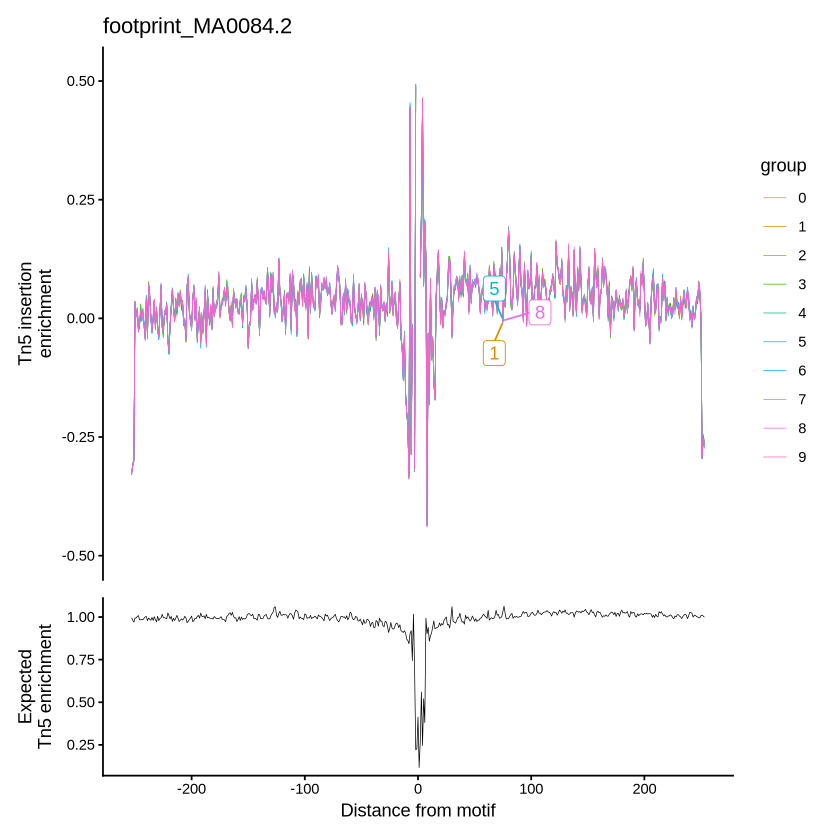

In [44]:
Signac::PlotFootprint(
    object = spot_rds_w_footprint,
    features = "footprint_MA0084.2",
    group.by = "leiden",
    show.expected = TRUE,
    normalization = "subtract"
  )